# This notebook contains the code for:
*   Data Preprocessing
*   The training & validation & testing of:
  *   SVM (Classical ML)
  *   RF (Classical ML)
  *   CNN (Deep Learning)
  *   LightGBM (Gradient Boosting Machines)









# Data Preprocessing

In [ ]:
# Pre-processing
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# List of dataset file names
dataset_files_list = ['DDoS_TCP_SYN_Flood_attack.csv', 'Distance.csv', 'IR_Receiver.csv', 'Temperature_and_Humidity.csv', 'Water_Level.csv']

# Path to the directory containing dataset files
data_path = '/content/drive/MyDrive/Senior/Dataset/'

# Initialize an empty DataFrame to store the sampled rows
sampled_df = pd.DataFrame()
# Columns to include in the sampled DataFrame
columns_to_include = ['frame.time', 'ip.src_host', 'ip.dst_host', 'tcp.ack', 'tcp.ack_raw','tcp.connection.syn','tcp.flags.ack',
                      'tcp.dstport','tcp.seq', 'tcp.srcport', 'Attack_label']

# Loop through the dataset files
for filename in dataset_files_list:
    # Read the file
    df = pd.read_csv(os.path.join(data_path, filename), usecols=columns_to_include)

    # Determine the number of rows to sample
    num_rows_to_sample = int(len(df) * 0.07)

    # Sample 7% of the rows
    sampled_rows = df.sample(n=num_rows_to_sample, random_state=42)

    # Concatenate the sampled rows to the sampled_df
    sampled_df = pd.concat([sampled_df, sampled_rows])

# Convert the 'frame.time' column to datetime
sampled_df['frame.time'] = pd.to_datetime(sampled_df['frame.time'])

# Sort the sampled dataframe based on the 'frame.time' column
sampled_df = sampled_df.sort_values(by='frame.time')

# Display the sampled dataframe
print(sampled_df)
# Drop rows where 'ip.src_host' or 'ip.dst_host' has a value of '0'
sampled_df = sampled_df[(sampled_df['ip.src_host'] != '0') & (sampled_df['ip.dst_host'] != '0')]

# Convert the 'frame.time' column to epoch time
sampled_df['frame.time'] = pd.to_datetime(sampled_df['frame.time']).astype(int) // 10**9

# Remove dots from IP addresses
ip_columns = ['ip.src_host', 'ip.dst_host']
for column in ip_columns:
    sampled_df[column] = sampled_df[column].str.replace('.', '').astype(int)

# Assuming sampled_df is your DataFrame
df = sampled_df

# Columns to check for zeros
columns_to_check = ['tcp.seq', 'tcp.srcport', 'tcp.ack', 'tcp.ack_raw', 'tcp.dstport']

# Values to check for zeros
zero_values = ['0', '0.0', '0.000000e+00']

# Create a boolean mask to identify rows with zeros in specified columns
mask = df[columns_to_check].astype(str).isin(zero_values).any(axis=1)

# Drop rows with zeros in specified columns
df = df[~mask]

# Print the updated DataFrame
print("DataFrame after dropping rows with zeros in specified columns:")
print(df)
df = df.dropna()
df = df.drop_duplicates()

# Remove 2% for testing
test_df = df.sample(frac=0.02, random_state=42)
# The rest is for training and validation
train_val_df = df.drop(test_df.index)
# Split the training and validation data into features (X) and labels (y)
y = train_val_df['Attack_label']
X = train_val_df.drop(columns=['Attack_label']).values

# Split the testing data into features (X) and labels (y)
y_test = test_df['Attack_label']
X_test = test_df.drop(columns=['Attack_label']).values


<ipython-input-3-5c972f7f1272>:35: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sampled_df['frame.time'] = pd.to_datetime(sampled_df['frame.time'])


                        frame.time    ip.src_host    ip.dst_host  tcp.ack  \
74157   2021-01-01 00:00:00.016533  192.168.1.128  192.168.1.101      0.0   
74175   2021-01-01 00:00:00.036491  192.168.1.101  192.168.1.128      1.0   
74185   2021-01-01 00:00:00.046156  192.168.1.128  192.168.1.101      0.0   
74249   2021-01-01 00:00:00.121184  192.168.1.101  192.168.1.128      6.0   
74250   2021-01-01 00:00:00.121217  192.168.1.128  192.168.1.101      0.0   
...                            ...            ...            ...      ...   
2295122 2022-01-01 23:09:13.823913   192.168.4.73   192.168.4.30      1.0   
2295132 2022-01-01 23:09:13.830546   192.168.4.73   192.168.4.30      0.0   
2295149 2022-01-01 23:09:13.852230   192.168.4.73   192.168.4.30      0.0   
2295205 2022-01-01 23:09:13.928630   192.168.4.73   192.168.4.30      6.0   
2295271 2022-01-01 23:09:14.040453   192.168.4.73   192.168.4.30      1.0   

          tcp.ack_raw  tcp.connection.syn  tcp.dstport  tcp.flags.ack  \
74

<ipython-input-3-5c972f7f1272>:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sampled_df['frame.time'] = pd.to_datetime(sampled_df['frame.time']).astype(int) // 10**9


DataFrame after dropping rows with zeros in specified columns:
         frame.time  ip.src_host  ip.dst_host  tcp.ack   tcp.ack_raw  \
74175    1609459200   1921681101   1921681128      1.0  1.204214e+09   
74249    1609459200   1921681101   1921681128      6.0  3.868316e+09   
74348    1609459200   1921681128   1921681101     15.0  2.722025e+09   
74350    1609459200   1921681128   1921681101     45.0  2.722025e+09   
74351    1609459200   1921681101   1921681128      5.0  1.139680e+08   
...             ...          ...          ...      ...           ...   
2295089  1641078553    192168430    192168473     15.0  1.636371e+09   
2295107  1641078553    192168473    192168430      1.0  4.214736e+07   
2295122  1641078553    192168473    192168430      1.0  3.202240e+09   
2295205  1641078553    192168473    192168430      6.0  1.316571e+09   
2295271  1641078554    192168473    192168430      1.0  2.528704e+09   

         tcp.connection.syn  tcp.dstport  tcp.flags.ack  tcp.seq  tcp.sr

To store the results

In [ ]:
# Define the base path
base_path = '/content/drive/MyDrive/ML_based_IDS/Models'

# Define specific folder paths for each model
svm_path = os.path.join(base_path, 'SVM/')
rf_path = os.path.join(base_path, 'RandomForest/')
cnn_path = os.path.join(base_path, 'ANN/')

# Create directories if they don't exist
os.makedirs(svm_path, exist_ok=True)
os.makedirs(rf_path, exist_ok=True)
os.makedirs(cnn_path, exist_ok=True)

# Define subfolders for logs, models, plots, and metrics within each model folder
subfolders = ['logs', 'models', 'plots', 'metrics']
for folder in [svm_path, rf_path, cnn_path]:
    for subfolder in subfolders:
        os.makedirs(os.path.join(folder, subfolder), exist_ok=True)

def save_metrics_to_csv(filename, accuracy, conf_matrix, classification_rep):
    # Save accuracy
    with open(filename, 'w') as f:
        f.write(f'Accuracy: {accuracy}\n\n')
        f.write('Confusion Matrix:\n')
        np.savetxt(f, conf_matrix, fmt='%d')
        f.write('\nClassification Report:\n')
        f.write(classification_rep)

def plot_confusion_matrix(conf_matrix, title, filename):
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Attack', 'Attack'], yticklabels=['No Attack', 'Attack'])
    plt.title(f'Confusion Matrix - {title}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig(filename)
    plt.close()

def plot_accuracy(history, title, filename):
    plt.figure(figsize=(8, 6))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Accuracy Over Epochs - {title}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.savefig(filename)
    plt.close()

# SVM

Training and validation

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import VarianceThreshold
import numpy as np
import time
import joblib

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the training, validation, and test sets
X_train = X_train / np.max(X_train)
X_val = X_val / np.max(X_val)
X_test = X_test / np.max(X_test)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Create an instance of VarianceThreshold
selector = VarianceThreshold()
X_train_scaled_no_const = selector.fit_transform(X_train_scaled)
X_val_scaled_no_const = selector.transform(X_val_scaled)
X_test_scaled_no_const = selector.transform(X_test_scaled)

# Create an SVM model (rbf kernel)
svm_model = SVC(kernel='rbf', random_state=42)

# Record the start time for training
train_start_time = time.time()

# Train the SVM model
svm_model.fit(X_train_scaled_no_const, y_train)

# Record the end time for training
train_end_time = time.time()

# Calculate the training time
training_time = train_end_time - train_start_time
print("Training Time:", training_time, "seconds")

# Make predictions on the training set
y_train_pred = svm_model.predict(X_train_scaled_no_const)

# Evaluate the model on training data
train_accuracy = accuracy_score(y_train, y_train_pred)
train_conf_matrix = confusion_matrix(y_train, y_train_pred)
train_classification_rep = classification_report(y_train, y_train_pred)

# Extract TP, TN, FP, and FN from the training confusion matrix
train_TN, train_FP, train_FN, train_TP = train_conf_matrix.ravel()

# Display the results for training
print("\nTraining Confusion Matrix:")
print(train_conf_matrix)
print(f"True Positives (TP): {train_TP}\n")
print(f"True Negatives (TN): {train_TN}\n")
print(f"False Positives (FP): {train_FP}\n")
print(f"False Negatives (FN): {train_FN}\n")
print(f"Training Accuracy: {train_accuracy:.4f}\n")
print("Training Classification Report:")
print(train_classification_rep)

# Record the start time for validation prediction
val_start_time = time.time()

# Make predictions on the validation set
y_val_pred = svm_model.predict(X_val_scaled_no_const)

# Record the end time for validation prediction
val_end_time = time.time()

# Calculate the validation prediction time
validation_time = val_end_time - val_start_time
print(f"Validation Prediction Time: {validation_time:.4f} seconds")

# Evaluate the model on validation data
val_accuracy = accuracy_score(y_val, y_val_pred)
val_conf_matrix = confusion_matrix(y_val, y_val_pred)
val_classification_rep = classification_report(y_val, y_val_pred)

# Extract TP, TN, FP, and FN from the validation confusion matrix
val_TN, val_FP, val_FN, val_TP = val_conf_matrix.ravel()

# Display the results for validation
print("\nValidation Confusion Matrix:")
print(val_conf_matrix)
print(f"True Positives (TP): {val_TP}\n")
print(f"True Negatives (TN): {val_TN}\n")
print(f"False Positives (FP): {val_FP}\n")
print(f"False Negatives (FN): {val_FN}\n")
print(f"Validation Accuracy: {val_accuracy:.4f}\n")
print("Validation Classification Report:")
print(val_classification_rep)

joblib.dump(svm_model, '/content/drive/MyDrive/ML_based_IDS/Models/SVM/models/model_filename.joblib')

Training Time: 369.9344720840454 seconds

Training Confusion Matrix:
[[238339     19]
 [     0  46094]]
True Positives (TP): 46094

True Negatives (TN): 238339

False Positives (FP): 19

False Negatives (FN): 0

Training Accuracy: 0.9999

Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    238358
           1       1.00      1.00      1.00     46094

    accuracy                           1.00    284452
   macro avg       1.00      1.00      1.00    284452
weighted avg       1.00      1.00      1.00    284452

Validation Prediction Time: 20.1179 seconds

Validation Confusion Matrix:
[[59620     6]
 [    0 11487]]
True Positives (TP): 11487

True Negatives (TN): 59620

False Positives (FP): 6

False Negatives (FN): 0

Validation Accuracy: 0.9999

Validation Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59626
           1       

['/content/drive/MyDrive/ML_based_IDS/Models/SVM/models/model_filename.joblib']

Testing

In [ ]:
# Evaluate the SVM model on the test data
test_start_time = time.time()
svm_y_test_pred = svm_model.predict(X_test_scaled_no_const)
test_end_time = time.time()
svm_test_time = test_end_time - test_start_time

svm_test_accuracy = accuracy_score(y_test, svm_y_test_pred)
svm_test_conf_matrix = confusion_matrix(y_test, svm_y_test_pred)
svm_test_classification_rep = classification_report(y_test, svm_y_test_pred)

print(f"SVM Test Prediction Time: {svm_test_time:.4f} seconds")
print(f"SVM Test Accuracy: {svm_test_accuracy}")
print("SVM Testing Classification Report:")
print(svm_test_classification_rep)

print("\nSVM Testing Confusion Matrix:")
print(svm_test_conf_matrix)

SVM Test Prediction Time: 1.2887 seconds
SVM Test Accuracy: 0.999725802029065
SVM Testing Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6142
           1       1.00      1.00      1.00      1152

    accuracy                           1.00      7294
   macro avg       1.00      1.00      1.00      7294
weighted avg       1.00      1.00      1.00      7294


SVM Testing Confusion Matrix:
[[6140    2]
 [   0 1152]]


Plotting and saving results

In [ ]:
# Save metrics to CSV
save_metrics_to_csv(os.path.join(svm_path, 'metrics/svm_metrics.csv'), svm_test_accuracy, svm_test_conf_matrix, svm_test_classification_rep)

# Plot confusion matrix
plot_confusion_matrix(svm_test_conf_matrix, 'SVM', os.path.join(svm_path, 'plots/svm_conf_matrix.png'))

# RF

Training and validation

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import time

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Create an instance of RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
# Record the start time for training
train_start_time = time.time()
rf_model.fit(X_train, y_train)
# Record the end time for training
train_end_time = time.time()

# Calculate the training time
training_time = train_end_time - train_start_time
print("Training Time:", training_time, "seconds")

# Make predictions on the training set
y_train_pred = rf_model.predict(X_train)

# Evaluate the model on training data
train_accuracy = accuracy_score(y_train, y_train_pred)
train_conf_matrix = confusion_matrix(y_train, y_train_pred)
train_classification_rep = classification_report(y_train, y_train_pred)

# Extract TP, TN, FP, and FN from the training confusion matrix
train_TN, train_FP, train_FN, train_TP = train_conf_matrix.ravel()

# Display the results for training
print("\nTraining Confusion Matrix:")
print(train_conf_matrix)
print(f"True Positives (TP): {train_TP}\n")
print(f"True Negatives (TN): {train_TN}\n")
print(f"False Positives (FP): {train_FP}\n")
print(f"False Negatives (FN): {train_FN}\n")
print(f"Training Accuracy: {train_accuracy:.4f}\n")
print("Training Classification Report:")
print(train_classification_rep)

# Record the start time for validation prediction
val_start_time = time.time()
# Make predictions on the validation set
y_val_pred = rf_model.predict(X_val)
# Record the end time for validation prediction
val_end_time = time.time()

# Calculate the validation prediction time
validation_time = val_end_time - val_start_time
print(f"Validation Prediction Time: {validation_time:.4f} seconds")

# Evaluate the model on validation data
val_accuracy = accuracy_score(y_val, y_val_pred)
val_conf_matrix = confusion_matrix(y_val, y_val_pred)
val_classification_rep = classification_report(y_val, y_val_pred)

# Extract TP, TN, FP, and FN from the validation confusion matrix
val_TN, val_FP, val_FN, val_TP = val_conf_matrix.ravel()

# Display the results for validation
print("\nValidation Confusion Matrix:")
print(val_conf_matrix)
print(f"True Positives (TP): {val_TP}\n")
print(f"True Negatives (TN): {val_TN}\n")
print(f"False Positives (FP): {val_FP}\n")
print(f"False Negatives (FN): {val_FN}\n")
print(f"Validation Accuracy: {val_accuracy:.4f}\n")
print("Validation Classification Report:")
print(val_classification_rep)

joblib.dump(rf_model, '/content/drive/MyDrive/ML_based_IDS/Models/RandomForest/models/random_forest_model.joblib')

Training Time: 10.883198022842407 seconds

Training Confusion Matrix:
[[238358      0]
 [     0  46094]]
True Positives (TP): 46094

True Negatives (TN): 238358

False Positives (FP): 0

False Negatives (FN): 0

Training Accuracy: 1.0000

Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    238358
           1       1.00      1.00      1.00     46094

    accuracy                           1.00    284452
   macro avg       1.00      1.00      1.00    284452
weighted avg       1.00      1.00      1.00    284452

Validation Prediction Time: 0.3373 seconds

Validation Confusion Matrix:
[[59626     0]
 [    0 11487]]
True Positives (TP): 11487

True Negatives (TN): 59626

False Positives (FP): 0

False Negatives (FN): 0

Validation Accuracy: 1.0000

Validation Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59626
           1       1

['/content/drive/MyDrive/ML_based_IDS/Models/RandomForest/models/random_forest_model.joblib']

Testing

In [ ]:
# Evaluate the Random Forest model on the test data
test_start_time = time.time()
rf_y_test_pred = rf_model.predict(X_test)
test_end_time = time.time()
rf_test_time = test_end_time - test_start_time

rf_test_accuracy = accuracy_score(y_test, rf_y_test_pred)
rf_test_conf_matrix = confusion_matrix(y_test, rf_y_test_pred)
rf_test_classification_rep = classification_report(y_test, rf_y_test_pred)

print(f"Random Forest Test Prediction Time: {rf_test_time:.4f} seconds")
print(f"Random Forest Test Accuracy: {rf_test_accuracy}")
print("Random Forest Testing Classification Report:")
print(rf_test_classification_rep)

print("\nRandom Forest Testing Confusion Matrix:")
print(rf_test_conf_matrix)

Random Forest Test Prediction Time: 0.0277 seconds
Random Forest Test Accuracy: 0.8420619687414314
Random Forest Testing Classification Report:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      6142
           1       0.00      0.00      0.00      1152

    accuracy                           0.84      7294
   macro avg       0.42      0.50      0.46      7294
weighted avg       0.71      0.84      0.77      7294


Random Forest Testing Confusion Matrix:
[[6142    0]
 [1152    0]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Plotting and saving results

In [ ]:
# Save metrics to CSV
save_metrics_to_csv(os.path.join(rf_path, 'metrics/rf_metrics.csv'), rf_test_accuracy, rf_test_conf_matrix, rf_test_classification_rep)

# Plot confusion matrix
plot_confusion_matrix(rf_test_conf_matrix, 'Random Forest', os.path.join(rf_path, 'plots/rf_conf_matrix.png'))

# ANN

Building the model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD

# 'input_shape': For tabular data, this will be the number of features in your dataset.
# 'drop': The dropout rate to be used in the dropout layers. Dropout is a regularization technique to prevent overfitting.
# 'lr': The learning rate for the optimizer.
# 'momentum': The momentum for the SGD optimizer, which helps accelerate gradients vectors in the right directions, thus leading to faster converging.
def make_model(input_shape, drop=0, lr=0.01, momentum=0.9):
    # Initialize the model(The Sequential model is a linear stack of layers)
    model = Sequential()
    # since we are training the model on tabular data we use dense(fully-connected) layers instead of conv layers
    # 64 is the number of neurons
    model.add(Dense(64, input_shape=input_shape, activation='relu'))
    model.add(Dropout(drop))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(drop))
    model.add(Dense(16, activation='relu'))
    # Add a dropout layer with the dropout rate specified by the drop parameter.
    # Dropout helps prevent overfitting by randomly setting a fraction of input units to 0 at each update during training
    model.add(Dropout(drop))
    # for binary classification (output layer)
    model.add(Dense(1, activation='sigmoid'))
    # Initializ the SGD (Stochastic Gradient Descent) optimizer with the specified learning rate and momentum.
    sgd = SGD(learning_rate=lr, momentum=momentum, nesterov=True)
    # compile the model and specify the loss func (binary_crossentropy; used for binary classifications), optimizer, and evaluation metrics
    model.compile(loss='binary_crossentropy', optimizer=sgd, metrics=['accuracy'])
    return model

Training and validation

In [ ]:
import numpy as np
import time
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint, Callback
from sklearn.model_selection import train_test_split

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the training, validation, and test sets
X_train = X_train / np.max(X_train)
X_val = X_val / np.max(X_val)
X_test = X_test / np.max(X_test)

# Define the path to save
path = '/content/drive/MyDrive/ML_based_IDS/Models/ANN/'

# Saving the info for this training
training_description = """
Training Details:
-----------------
Learning Rate: 0.01
Dropout Rate: 0.5
Batch Size: 32
Epochs: 100
"""
with open(path + 'Train_description.txt', 'w') as f:
    f.write(training_description)

# Callback to log training time
class TimeHistory(Callback):
    def on_train_begin(self, logs={}):
        self.times = []

    def on_epoch_begin(self, epoch, logs={}):
        self.epoch_time_start = time.time()

    def on_epoch_end(self, epoch, logs={}):
        self.times.append(time.time() - self.epoch_time_start)
        # Log the training time for this epoch
        with open(os.path.join(path, 'training_time_log.txt'), 'a') as f:
            f.write(f'Epoch {epoch + 1}, Training Time: {self.times[-1]:.4f} seconds\n')

# Define the callbacks
logger = CSVLogger(path + 'logANN.csv', append=True)
checkpt = ModelCheckpoint(path + 'ANN_model.{epoch:02d}-{val_accuracy:.2f}.h5',
                          save_best_only=True,
                          monitor='val_accuracy',
                          mode='max',
                          save_freq='epoch')
time_callback = TimeHistory()

# Call the building function
input_shape = (X_train.shape[1],)
model = make_model(input_shape=input_shape, drop=0.5, lr=0.01, momentum=0.9)

# Track training time
train_start_time = time.time()

# Fit the model using the fit method
history = model.fit(X_train, y_train,
                    batch_size=32,
                    epochs=100,
                    verbose=2,
                    validation_data=(X_val, y_val),
                    callbacks=[logger, checkpt, time_callback])

train_end_time = time.time()

# Calculate the training time
training_time = train_end_time - train_start_time
print("Training Time:", training_time, "seconds")

# Save the final model
model.save(path + 'finalANN.h5')

# Plot training and validation accuracy
plot_accuracy(history, 'ANN', path + 'Ann_accuracy.png')


Epoch 1/100
8890/8890 - 31s - loss: 0.3356 - accuracy: 0.8881 - val_loss: 0.3143 - val_accuracy: 0.8963 - 31s/epoch - 3ms/step
Epoch 2/100
8890/8890 - 22s - loss: 0.3487 - accuracy: 0.8846 - val_loss: 0.3379 - val_accuracy: 0.8784 - 22s/epoch - 2ms/step
Epoch 3/100
8890/8890 - 19s - loss: 0.3511 - accuracy: 0.8837 - val_loss: 0.3177 - val_accuracy: 0.8978 - 19s/epoch - 2ms/step
Epoch 4/100
8890/8890 - 19s - loss: 0.3551 - accuracy: 0.8824 - val_loss: 0.3203 - val_accuracy: 0.8967 - 19s/epoch - 2ms/step
Epoch 5/100
8890/8890 - 19s - loss: 0.3526 - accuracy: 0.8835 - val_loss: 0.2770 - val_accuracy: 0.9188 - 19s/epoch - 2ms/step
Epoch 6/100
8890/8890 - 22s - loss: 0.3514 - accuracy: 0.8843 - val_loss: 0.3061 - val_accuracy: 0.9020 - 22s/epoch - 2ms/step
Epoch 7/100
8890/8890 - 21s - loss: 0.3552 - accuracy: 0.8826 - val_loss: 0.3134 - val_accuracy: 0.9022 - 21s/epoch - 2ms/step
Epoch 8/100
8890/8890 - 24s - loss: 0.3511 - accuracy: 0.8845 - val_loss: 0.3671 - val_accuracy: 0.8773 - 24s/e

ValueError: could not convert string to float: 'Time:'

In [ ]:
import json
# Save the history to a JSON file
history_dict = history.history
with open('/content/drive/MyDrive/ML_based_IDS/Models/ANN/logs/history.json', 'w') as f:
    json.dump(history_dict, f)

Testing

In [ ]:
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix

# Load the trained model
model = load_model(path + 'finalANN.h5')

# Evaluate the model on the test data
test_start_time = time.time()
ann_loss, ann_accuracy = model.evaluate(X_test, y_test, verbose=2)
test_end_time = time.time()
ann_test_time = test_end_time - test_start_time

print(f'Test Loss: {ann_loss}')
print(f'Test Accuracy: {ann_accuracy}')
print(f"Test Prediction Time: {ann_test_time:.4f} seconds")

# Generate predictions on the test data
ann_y_test_pred = model.predict(X_test)
# Convert probabilities to binary predictions
ann_y_test_pred_classes = (ann_y_test_pred > 0.5).astype("int32")

# Classification report
ann_test_classification_rep = classification_report(y_test, ann_y_test_pred_classes, target_names=['No Attack', 'Attack'])
print("ANN Testing Classification Report:")
print(ann_test_classification_rep)

# Confusion matrix
ann_test_conf_matrix = confusion_matrix(y_test, ann_y_test_pred_classes)
print("\nANN Testing Confusion Matrix:")
print(ann_test_conf_matrix)
ann_test_TN, ann_test_FP, ann_test_FN, ann_test_TP = ann_test_conf_matrix.ravel()
print(f"True Positives (TP): {ann_test_TP}\n")
print(f"True Negatives (TN): {ann_test_TN}\n")
print(f"False Positives (FP): {ann_test_FP}\n")
print(f"False Negatives (FN): {ann_test_FN}\n")

228/228 - 2s - loss: 0.2455 - accuracy: 0.9310 - 2s/epoch - 7ms/step
Test Loss: 0.24548646807670593
Test Accuracy: 0.9310392141342163
Test Prediction Time: 2.0024 seconds
228/228 [==============================] - 2s 5ms/step
CNN Testing Classification Report:
              precision    recall  f1-score   support

   No Attack       0.92      1.00      0.96      6142
      Attack       1.00      0.56      0.72      1152

    accuracy                           0.93      7294
   macro avg       0.96      0.78      0.84      7294
weighted avg       0.94      0.93      0.92      7294


CNN Testing Confusion Matrix:
[[6142    0]
 [ 503  649]]
True Positives (TP): 649

True Negatives (TN): 6142

False Positives (FP): 0

False Negatives (FN): 503



Plotting and saving results

In [ ]:
import matplotlib.pyplot as plt
import os

train_accuracies = history.history['accuracy']
val_accuracies = history.history['val_accuracy']

# Define the path to save
path = '/content/drive/MyDrive/ML_based_IDS/Models/CNN/'

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Training Accuracy')
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label='Validation Accuracy')
plt.title('Accuracy Over Epochs - ANN')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig(os.path.join(path, 'plots/ann_accuracy.png'))
plt.close()

log_path = os.path.join(path, 'training_time_log.txt')

with open(log_path, 'r') as f:
    total_training_time = sum(float(line.split(':')[1].strip().split()[0]) for line in f.readlines())

print("Total Training Time:", total_training_time, "seconds")


Total Training Time: 2160.2545999999998 seconds


# LightGBM

Training and validation

In [ ]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Define hyperparameters
params = {
    "objective": "binary",
    "boosting_type": "rf",  # Random Forest boosting
    "num_leaves": 500,
    "force_row_wise": True,
    "learning_rate": 1.0,
    "metric": "binary_logloss",
    "bagging_fraction": 0.1,
    "feature_fraction": 0.1,
    "lambda_l1": 50.0,
    "lambda_l2": 50.0,
    "min_data_in_leaf": 10000
}


lgbm_model = lgb.LGBMClassifier(**params, num_boost_round = 10)
# Record the start time for training
train_start_time = time.time()
# Train the model
lgbm_model.fit(X_train, y_train)
# Record the end time for training
train_end_time = time.time()

# Calculate the training time
training_time = train_end_time - train_start_time
print("Training Time:", training_time, "seconds")
# Make predictions on the training set
y_train_pred = lgbm_model.predict(X_train)

# Evaluate the model on training data
train_accuracy = accuracy_score(y_train, y_train_pred)
train_conf_matrix = confusion_matrix(y_train, y_train_pred)
train_classification_rep = classification_report(y_train, y_train_pred)

# Extract TP, TN, FP, and FN from the training confusion matrix
train_TN, train_FP, train_FN, train_TP = train_conf_matrix.ravel()

# Display the results for training
print("\nTraining Confusion Matrix:")
print(train_conf_matrix)
print(f"True Positives (TP): {train_TP}\n")
print(f"True Negatives (TN): {train_TN}\n")
print(f"False Positives (FP): {train_FP}\n")
print(f"False Negatives (FN): {train_FN}\n")
print(f"Training Accuracy: {train_accuracy:.4f}\n")
print("Training Classification Report:")
print(train_classification_rep)

# Record the start time for validation prediction
val_start_time = time.time()
# Make predictions on the validation set
y_val_pred = lgbm_model.predict(X_val)
# Record the end time for validation prediction
val_end_time = time.time()

# Calculate the validation prediction time
validation_time = val_end_time - val_start_time
print(f"Validation Prediction Time: {validation_time:.4f} seconds")

# Evaluate the model on validation data
val_accuracy = accuracy_score(y_val, y_val_pred)
val_conf_matrix = confusion_matrix(y_val, y_val_pred)
val_classification_rep = classification_report(y_val, y_val_pred)

# Extract TP, TN, FP, and FN from the validation confusion matrix
val_TN, val_FP, val_FN, val_TP = val_conf_matrix.ravel()

# Display the results for validation
print("\nValidation Confusion Matrix:")
print(val_conf_matrix)
print(f"True Positives (TP): {val_TP}\n")
print(f"True Negatives (TN): {val_TN}\n")
print(f"False Positives (FP): {val_FP}\n")
print(f"False Negatives (FN): {val_FN}\n")
print(f"Validation Accuracy: {val_accuracy:.4f}\n")
print("Validation Classification Report:")
print(val_classification_rep)

/usr/local/lib/python3.10/dist-packages/lightgbm/engine.py:172: UserWarning: Found `num_boost_round` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


[LightGBM] [Warning] min_data_in_leaf is set=10000, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10000
[LightGBM] [Warning] feature_fraction is set=0.1, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.1
[LightGBM] [Warning] lambda_l2 is set=50.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=50.0
[LightGBM] [Warning] lambda_l1 is set=50.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=50.0
[LightGBM] [Warning] num_iterations is set=10, num_boost_round=10 will be ignored. Current value: num_iterations=10
[LightGBM] [Warning] bagging_fraction is set=0.1, subsample=1.0 will be ignored. Current value: bagging_fraction=0.1
[LightGBM] [Warning] min_data_in_leaf is set=10000, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10000
[LightGBM] [Warning] feature_fraction is set=0.1, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.1
[LightGBM] [Warning] lambda_l2 is set=50.0, reg_lamb

In [ ]:
joblib.dump(lgbm_model, '/content/drive/MyDrive/ML_based_IDS/Models/LightGBM/models/lightgbm_model.joblib')

['/content/drive/MyDrive/ML_based_IDS/Models/LightGBM/models/lightgbm_model.joblib']

Testing

In [ ]:
# Evaluate the Random Forest model on the test data
test_start_time = time.time()
lgbm_y_test_pred = lgbm_model.predict(X_test)
test_end_time = time.time()
lgbm_test_time = test_end_time - test_start_time

lgbm_test_accuracy = accuracy_score(y_test, lgbm_y_test_pred)
lgbm_test_conf_matrix = confusion_matrix(y_test, lgbm_y_test_pred)
lgbm_test_classification_rep = classification_report(y_test, lgbm_y_test_pred)

print(f"LightGBM Test Prediction Time: {lgbm_test_time:.4f} seconds")
print(f"LightGBM Test Accuracy: {lgbm_test_accuracy}")
print("LightGBM Testing Classification Report:")
print(lgbm_test_classification_rep)

print("\nLightGBM Testing Confusion Matrix:")
print(lgbm_test_conf_matrix)

[LightGBM] [Warning] min_data_in_leaf is set=10000, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10000
[LightGBM] [Warning] feature_fraction is set=0.1, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.1
[LightGBM] [Warning] lambda_l2 is set=50.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=50.0
[LightGBM] [Warning] lambda_l1 is set=50.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=50.0
[LightGBM] [Warning] bagging_fraction is set=0.1, subsample=1.0 will be ignored. Current value: bagging_fraction=0.1
LightGBM Test Prediction Time: 0.0164 seconds
LightGBM Test Accuracy: 0.8420619687414314
LightGBM Testing Classification Report:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      6142
           1       0.00      0.00      0.00      1152

    accuracy                           0.84      7294
   macro avg       0.42      0.50      0.46      7294
weighted avg       

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Plotting and saving the results

In [ ]:
# Save metrics to CSV
save_metrics_to_csv('/content/drive/MyDrive/ML_based_IDS/Models/LightGBM/metrics/svm_metrics.csv', lgbm_test_accuracy, lgbm_test_conf_matrix, lgbm_test_classification_rep)

# Plot confusion matrix
plot_confusion_matrix(lgbm_test_conf_matrix, 'LightGBM', '/content/drive/MyDrive/ML_based_IDS/Models/LightGBM/plots/svm_conf_matrix.png')

# More plots

In [ ]:
import joblib
from tensorflow.keras.models import load_model

# Paths to your saved models
rf_model_path = '/content/drive/MyDrive/ML_based_IDS/Models/RandomForest/models/random_forest_model.joblib'
svm_model_path = '/content/drive/MyDrive/ML_based_IDS/Models/SVM/models/svm_model.joblib'
lgbm_model_path = '/content/drive/MyDrive/ML_based_IDS/Models/LightGBM/models/lightgbm_model.joblib'
cnn_model_path = '/content/drive/MyDrive/ML_based_IDS/Models/CNN/models/finalCNN.h5'

# Load models
rf_model = joblib.load(rf_model_path)
svm_model = joblib.load(svm_model_path)
lgbm_model = joblib.load(lgbm_model_path)
cnn_model = load_model(cnn_model_path)


Plotting ROC Curve for Random Forest

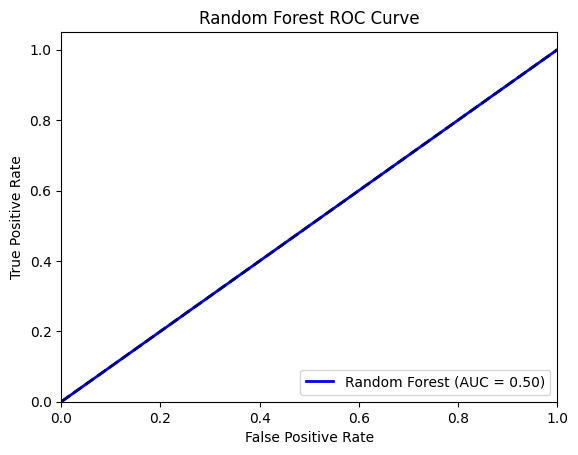

In [ ]:
from sklearn.metrics import roc_curve, auc

# Predict probabilities
y_test_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC curve
plt.figure()
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend(loc="lower right")
plt.savefig('/content/drive/MyDrive/ML_based_IDS/Models/RandomForest/plots/rf_roc_curve.png')
plt.show()


Precision-Recall Curve for Random Forest

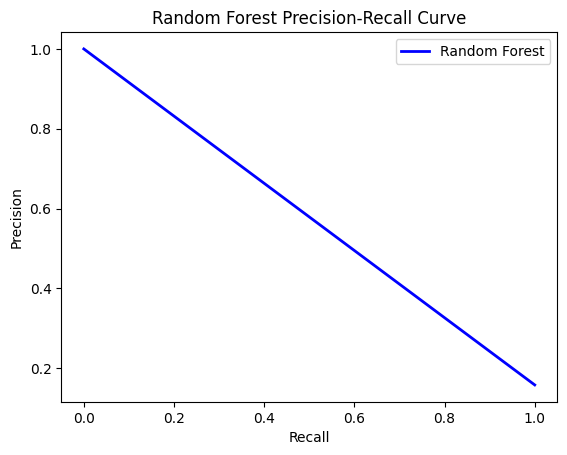

In [ ]:
from sklearn.metrics import precision_recall_curve

precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_test_prob_rf)

plt.figure()
plt.plot(recall_rf, precision_rf, color='blue', lw=2, label='Random Forest')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Random Forest Precision-Recall Curve')
plt.legend(loc="upper right")
plt.savefig('/content/drive/MyDrive/ML_based_IDS/Models/RandomForest/plots/rf_pr_curve.png')
plt.show()

Plotting ROC Curve for SVM

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

# Assuming these were your preprocessing steps during training
scaler = StandardScaler()
selector = VarianceThreshold()

# Apply to training data
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled_no_const = selector.fit_transform(X_train_scaled)

# Apply to validation data
X_val_scaled = scaler.transform(X_val)
X_val_scaled_no_const = selector.transform(X_val_scaled)

# Apply to test data
X_test_scaled = scaler.transform(X_test)
X_test_scaled_no_const = selector.transform(X_test_scaled)

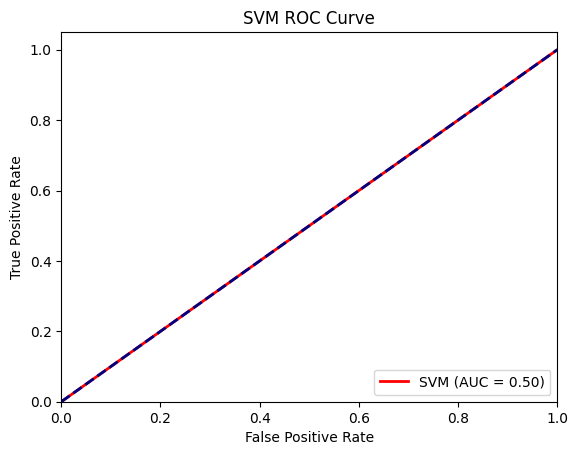

In [ ]:
# Apply consistent preprocessing to test data
X_test_scaled = scaler.transform(X_test)
X_test_scaled_no_const = selector.transform(X_test_scaled)

# Predict using the SVM model
y_test_prob_svm = svm_model.decision_function(X_test_scaled_no_const)

# Calculate ROC curve and AUC
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_test_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

# Plot ROC curve
plt.figure()
plt.plot(fpr_svm, tpr_svm, color='red', lw=2, label=f'SVM (AUC = {roc_auc_svm:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve')
plt.legend(loc="lower right")
plt.savefig('/content/drive/MyDrive/ML_based_IDS/Models/SVM/plots/svm_roc_curve.png')
plt.show()

Precision-Recall Curve for SVM

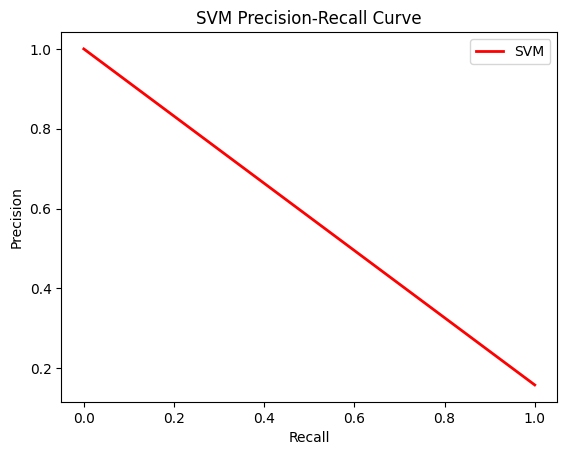

In [ ]:
precision_svm, recall_svm, _ = precision_recall_curve(y_test, y_test_prob_svm)

plt.figure()
plt.plot(recall_svm, precision_svm, color='red', lw=2, label='SVM')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('SVM Precision-Recall Curve')
plt.legend(loc="upper right")
plt.savefig('/content/drive/MyDrive/ML_based_IDS/Models/SVM/plots/svm_pr_curve.png')
plt.show()

Plotting Feature Importance for LightGBM

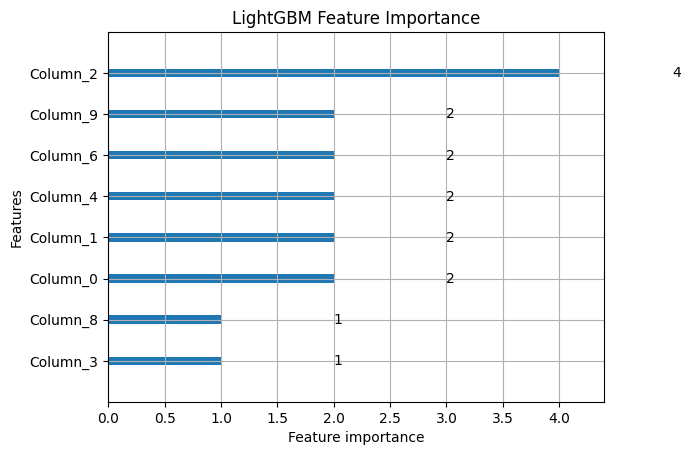

In [ ]:
import lightgbm as lgb
import matplotlib.pyplot as plt

ax = lgb.plot_importance(lgbm_model, max_num_features=10)
plt.title('LightGBM Feature Importance')
plt.savefig('/content/drive/MyDrive/ML_based_IDS/Models/LightGBM/plots/lgbm_feature_importance.png')
plt.show()

Plotting ROC Curve for LightGBM

[LightGBM] [Warning] min_data_in_leaf is set=10000, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10000
[LightGBM] [Warning] feature_fraction is set=0.1, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.1
[LightGBM] [Warning] lambda_l2 is set=50.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=50.0
[LightGBM] [Warning] lambda_l1 is set=50.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=50.0
[LightGBM] [Warning] bagging_fraction is set=0.1, subsample=1.0 will be ignored. Current value: bagging_fraction=0.1


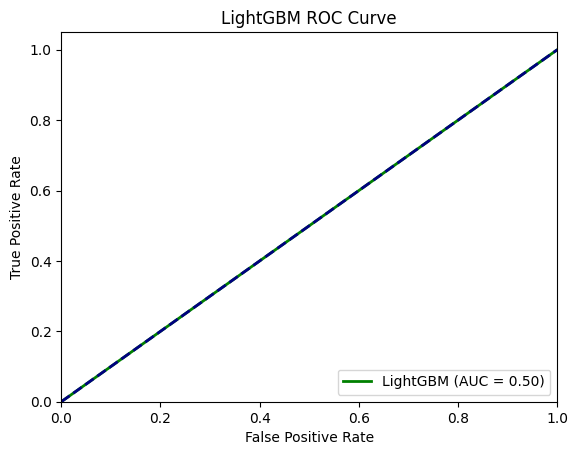

In [ ]:
y_test_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_test_prob_lgbm)
roc_auc_lgbm = auc(fpr_lgbm, tpr_lgbm)

# Plot ROC curve
plt.figure()
plt.plot(fpr_lgbm, tpr_lgbm, color='green', lw=2, label=f'LightGBM (AUC = {roc_auc_lgbm:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LightGBM ROC Curve')
plt.legend(loc="lower right")
plt.savefig('/content/drive/MyDrive/ML_based_IDS/Models/LightGBM/plots/lgbm_roc_curve.png')
plt.show()

Precision-Recall Curve for LightGBM

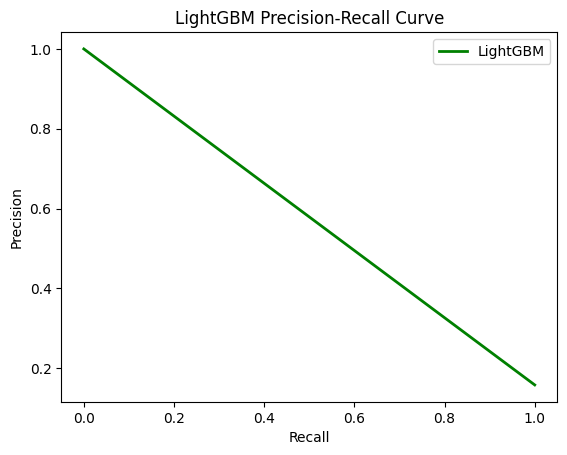

In [ ]:
precision_lgbm, recall_lgbm, _ = precision_recall_curve(y_test, y_test_prob_lgbm)

plt.figure()
plt.plot(recall_lgbm, precision_lgbm, color='green', lw=2, label='LightGBM')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('LightGBM Precision-Recall Curve')
plt.legend(loc="upper right")
plt.savefig('/content/drive/MyDrive/ML_based_IDS/Models/LightGBM/plots/lgbm_pr_curve.png')
plt.show()

Plotting ROC Curve for ANN

228/228 [==============================] - 0s 1ms/step


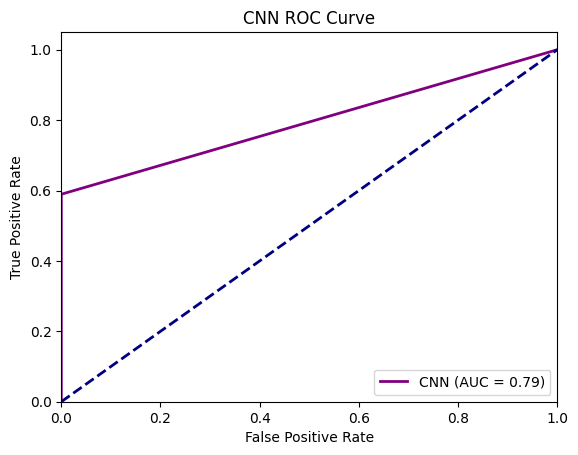

In [ ]:
y_test_prob_ann = cnn_model.predict(X_test).ravel()

# Calculate ROC curve and AUC
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_test_prob_cnn)
roc_auc_ann = auc(fpr_ann, tpr_ann)

# Plot ROC curve
plt.figure()
plt.plot(fpr_ann, tpr_ann, color='purple', lw=2, label=f'ANN (AUC = {roc_auc_ann:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ANN ROC Curve')
plt.legend(loc="lower right")
plt.savefig('/content/drive/MyDrive/ML_based_IDS/Models/CNN/plots/cnn_roc_curve.png')
plt.show()